# 1) Title and Goals

This project compares five different classifiers on the MNIST handwritten digit dataset. The goal is to show where each model "looked" to make its decision, using one simple rule: **brighter = mattered more**.

We will cover:
* **Easy Wins:** Cases where the CNN is right and other models fail.
* **Tricky Cases:** Ambiguous digits where all models struggle, helping to tell a complete story about the strengths and limits of each approach.

## 2) Setup and Imports

In [ ]:
# Minimal, seminar-ready setup: scikit-learn + TensorFlow/Keras + matplotlib
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## 3) Load MNIST Data

In [ ]:
# MNIST: 70,000 grayscale images of 28x28 pixels
# Use first 60k for training, last 10k for testing
mnist = fetch_openml(name="mnist_784", version=1, as_frame=False, parser="auto")

# Normalize pixel values to [0, 1] and set types
X = mnist.data.astype("float32") / 255.0
y = mnist.target.astype(int)

# Standard 60k/10k split
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print(f"Train data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:75: RuntimeWarning: Invalid cache, redownloading file
  warn("Invalid cache, redownloading file", RuntimeWarning)


Train data shape: (60000, 784)
Test data shape: (10000, 784)


**Explanation:** MNIST is a classic benchmark for digit recognition. Scaling pixel values to `[0, 1]` matches common Keras and scikit-learn recipes and keeps models stable across comparisons.

## 4) Define Models

In [ ]:
# Classic scikit-learn models
models_sklearn = {
    "KNN": KNeighborsClassifier(n_neighbors=3),      # k = 3
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "NaiveBayes": GaussianNB(),
    "MLP": MLPClassifier(random_state=42, max_iter=200), # Default max_iter is 200
}

# Compact CNN (Keras) — simple 2×Conv + MaxPool + Dense head
def build_cnn():
    m = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.25),
        layers.Dense(10, activation="softmax"),
    ])
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

**Explanation:** KNN (k=3), Decision Tree, Gaussian Naive Bayes, and MLP capture instance-based, rule-based, probabilistic, and shallow neural baselines. A small CNN provides a strong, widely used MNIST reference that often attains ~99% accuracy.

## 5) Train Models

In [ ]:
# Fit scikit-learn models
print("Training scikit-learn models...")
for name, clf in models_sklearn.items():
    print(f"Training {name}...")
    clf.fit(X_train, y_train)
print("Scikit-learn models trained.")

# Fit CNN
# Reshape data for CNN (needs 28x28x1 image format)
X_train_img, X_test_img = X_train.reshape(-1, 28, 28, 1), X_test.reshape(-1, 28, 28, 1)

cnn = build_cnn()
callbacks = [keras.callbacks.EarlyStopping(patience=2, monitor="val_accuracy", restore_best_weights=True)]

print("\nTraining CNN...")
cnn.fit(X_train_img, y_train,
          validation_split=0.1,
          epochs=8,
          batch_size=128,
          callbacks=callbacks,
          verbose=2)

Training scikit-learn models...
Training KNN...
Training DecisionTree...
Training NaiveBayes...
Training MLP...
Scikit-learn models trained.

Training CNN...
Epoch 1/8
422/422 - 44s - 105ms/step - accuracy: 0.9284 - loss: 0.2411 - val_accuracy: 0.9833 - val_loss: 0.0605
Epoch 2/8
422/422 - 79s - 188ms/step - accuracy: 0.9780 - loss: 0.0713 - val_accuracy: 0.9872 - val_loss: 0.0478
Epoch 3/8
422/422 - 40s - 95ms/step - accuracy: 0.9841 - loss: 0.0511 - val_accuracy: 0.9892 - val_loss: 0.0391
Epoch 4/8
422/422 - 41s - 98ms/step - accuracy: 0.9876 - loss: 0.0382 - val_accuracy: 0.9907 - val_loss: 0.0373
Epoch 5/8
422/422 - 43s - 101ms/step - accuracy: 0.9898 - loss: 0.0315 - val_accuracy: 0.9902 - val_loss: 0.0368
Epoch 6/8
422/422 - 80s - 188ms/step - accuracy: 0.9918 - loss: 0.0267 - val_accuracy: 0.9922 - val_loss: 0.0330
Epoch 7/8
422/422 - 41s - 96ms/step - accuracy: 0.9924 - loss: 0.0227 - val_accuracy: 0.9908 - val_loss: 0.0344
Epoch 8/8
422/422 - 40s - 96ms/step - accuracy: 0.9930

**Explanation:** Training follows library defaults so the focus is on side-by-side comparability. The CNN setup mirrors the common Keras MNIST convnet example for reliable results, using an 8-epoch limit with early stopping.

## 6) Evaluate Accuracy

In [ ]:
# Get predictions from scikit-learn models
preds = {name: clf.predict(X_test) for name, clf in models_sklearn.items()}
accs  = {name: accuracy_score(y_test, preds[name]) for name in models_sklearn}

# CNN evaluation
test_loss, test_acc = cnn.evaluate(X_test_img, y_test, verbose=0)
accs["CNN"] = float(test_acc)

print("--- Model Test Accuracies ---")
for name in ["KNN","DecisionTree","NaiveBayes","MLP","CNN"]:
    print(f"{name:<13} accuracy: {accs[name]:.2%}")

--- Model Test Accuracies ---
KNN           accuracy: 97.05%
DecisionTree  accuracy: 87.54%
NaiveBayes    accuracy: 55.58%
MLP           accuracy: 97.75%
CNN           accuracy: 99.02%


**Explanation:** Reporting consistent test-set accuracy enables a fair comparison on identical data splits. As expected, simple convnets typically reach about 99% on MNIST, significantly outperforming the other models.

## 7) Simple Overlays: Brighter = Mattered More

To keep explanations non-technical, we use a simple **occlusion** method:
1.  Hide a small patch of the image.
2.  Measure how much the predicted class score drops.
3.  A larger drop means the model relied on that area more, so it’s shown brighter on the overlay.

For **Naive Bayes**, we compute a per-pixel contribution map from its class-wise means and variances. This avoids flat overlays (since small occlusions barely move its probabilities) and remains faithful to the model’s internal structure.

This animation shows a black square (the occlusion patch) systematically moving across the selected digit image. Each frame represents one step in the occlusion process. By observing how the model's prediction confidence changes when different parts are hidden, we can infer which regions are most crucial for its decision-making, leading to the 'brighter = mattered more' overlays.

## 8) Overlay Helper Functions

In [ ]:
def predict_proba_any(model, x_img):
    """Works for scikit-learn (predict_proba) and Keras CNN (predict)"""
    if hasattr(model, "predict_proba"): # scikit-learn models
        return model.predict_proba(x_img.reshape(1, -1))[0]
    # Keras CNN
    x = x_img.reshape(1, 28, 28, 1).astype("float32")
    return model.predict(x, verbose=0)[0]

def simple_importance_map_any(model, x_img, window=4, stride=2, model_name=None):
    """Occlusion-based importance map for any model"""
    H, W = x_img.shape
    base_proba = predict_proba_any(model, x_img)
    pred = int(np.argmax(base_proba)); base = float(base_proba[pred])

    # Stronger occlusion for KNN/NB; dual black/white masking; top-10% mask for contrast
    if model_name in {"KNN", "NaiveBayes"}:
        window, stride = max(window, 7), min(stride, 2)

    imp = np.zeros((H, W), dtype=float); cnt = np.zeros((H, W), dtype=float)

    for r in range(0, H - window + 1, stride):
        for c in range(0, W - window + 1, stride):
            # Occlude with black
            xb = x_img.copy(); xb[r:r+window, c:c+window] = 0.0
            # Occlude with white
            xw = x_img.copy(); xw[r:r+window, c:c+window] = 1.0

            # Measure the max drop in probability from either occlusion
            drop_b = max(0.0, base - float(predict_proba_any(model, xb)[pred]))
            drop_w = max(0.0, base - float(predict_proba_any(model, xw)[pred]))
            drop = max(drop_b, drop_w)

            imp[r:r+window, c:c+window] += drop; cnt[r:r+window, c:c+window] += 1.0

    cnt[cnt == 0] = 1.0; imp /= cnt # Average contribution
    q = np.quantile(imp, 0.90); mask = (imp >= q) & (imp > 0)
    return imp, pred, base, mask

def nb_pixel_contrib(gnb, x_img, pred_class):
    """GaussianNB per-pixel contribution (higher => fits predicted class better)"""
    mu = gnb.theta_[pred_class].reshape(28, 28)
    # Handle change in attribute name from 'sigma_' to 'var_' in sklearn 1.0
    var_attr = getattr(gnb, "var_", None)
    if var_attr is None:
      var_attr = getattr(gnb, "sigma_", None)
    var = var_attr[pred_class].reshape(28, 28) + 1e-9 # Add epsilon for stability

    # Log-probability of Gaussian density (ignoring constant term)
    return -0.5 * ((x_img - mu) ** 2 / var) - 0.5 * np.log(var)

def show_row(idx, x_img, y_true, panels, cohort_title):
    """Helper to plot a full row of comparisons"""
    # panels: list of (name, overlay, pred, conf, ok, mask_or_None) in order
    fig, axes = plt.subplots(1, 6, figsize=(19, 3.8))

    # Plot original image
    axes[0].imshow(x_img, cmap="gray");
    axes[0].set_title(f"{cohort_title}\nOriginal\nTrue: {y_true}", fontsize=11);
    axes[0].axis("off")

    # Plot each model's explanation
    for j, (name, overlay, pred, conf, ok, mask) in enumerate(panels, start=1):
        axes[j].imshow(x_img, cmap="gray", alpha=0.8)
        shown = False

        if mask is not None and np.any(mask):
            vmax = np.percentile(overlay[mask], 99.0) if np.any(overlay[mask]) else None
            if vmax and vmax > 0:
                ov = np.zeros_like(overlay); ov[mask] = overlay[mask]
                axes[j].imshow(ov, cmap="YlOrRd", alpha=0.75, vmin=0.0, vmax=vmax); shown = True
        else:
            # Fallback for NaiveBayes or other non-masked overlays
            abs_top = np.abs(overlay) >= np.quantile(np.abs(overlay), 0.90)
            if np.any(abs_top):
                vmax = np.percentile(np.abs(overlay[abs_top]), 99.0)
                # Show only positive contributions for clarity
                axes[j].imshow(np.maximum(overlay, 0), cmap="YlOrRd", alpha=0.75, vmin=0.0, vmax=max(vmax, 1e-6)); shown = True

        status = "✓" if ok else "✗"
        title_color = ("green" if ok else "red")
        axes[j].set_title(f"{name}\nPred: {pred} • {conf:.0%} {status}", fontsize=11, color=title_color)

        if not shown:
            axes[j].text(0.5,0.5,"No standout region",color="orange",ha="center",va="center",transform=axes[j].transAxes)
        axes[j].axis("off")

    plt.tight_layout(); plt.show()

**Explanation:** Hiding patches (occlusion) and measuring the drop in the score gives a simple, visual notion of “attention.” The Naive Bayes’ per-pixel Gaussian view provides a faithful, always-informative overlay even when occlusion changes are tiny.

## 9) Select Cohorts (Example Groups)

In [ ]:
# Get all predictions first
proba_cnn = cnn.predict(X_test_img, verbose=0)
preds = {name: models_sklearn[name].predict(X_test) for name in models_sklearn}
accs = {name: accuracy_score(y_test, preds[name]) for name in models_sklearn}
preds["CNN"] = np.argmax(proba_cnn, axis=1)
accs["CNN"] = accuracy_score(y_test, preds["CNN"])

# Create correctness masks
corrects = {name: (preds[name] == y_test) for name in preds}
all_correct = corrects["KNN"] & corrects["DecisionTree"] & corrects["NaiveBayes"] & corrects["MLP"] & corrects["CNN"]
cnn_right_others_wrong = corrects["CNN"] & (~corrects["KNN"] | ~corrects["DecisionTree"] | ~corrects["NaiveBayes"] | ~corrects["MLP"])
all_wrong = (~corrects["KNN"]) & (~corrects["DecisionTree"]) & (~corrects["NaiveBayes"]) & (~corrects["MLP"]) & (~corrects["CNN"])

def pick(mask, k, seed):
    """Helper to pick k indices from a boolean mask"""
    idxs = np.where(mask)[0]
    if idxs.size == 0: # Fallback if mask is empty
        print(f"Warning: No examples found for mask. Picking random examples.")
        rng = np.random.RandomState(seed)
        return rng.choice(X_test.shape[0], size=min(k, X_test.shape[0]), replace=False)
    # Pick from the start of the found indices for consistency
    return idxs[:k]

# Select 3 cohorts
idxs_all_correct = pick(all_correct, 6, 123)
idxs_cnn_wins = pick(cnn_right_others_wrong, 10, 456)
idxs_all_wrong = pick(all_wrong, 6, 789)

print(f"Found {len(np.where(all_correct)[0])} examples all models got right.")
print(f"Found {len(np.where(cnn_right_others_wrong)[0])} examples where CNN won.")
print(f"Found {len(np.where(all_wrong)[0])} examples all models got wrong.")

Found 5027 examples all models got right.
Found 4882 examples where CNN won.
Found 21 examples all models got wrong.


**Explanation:** Showing “All Correct” builds intuition. “CNN Right, Others Wrong” highlights why CNNs excel on images. “All Wrong” shows hard cases and is a great way to discuss data limitations.

## 10) Render Cohort Comparisons


=== Cohort 1: All Correct (6 examples) ===


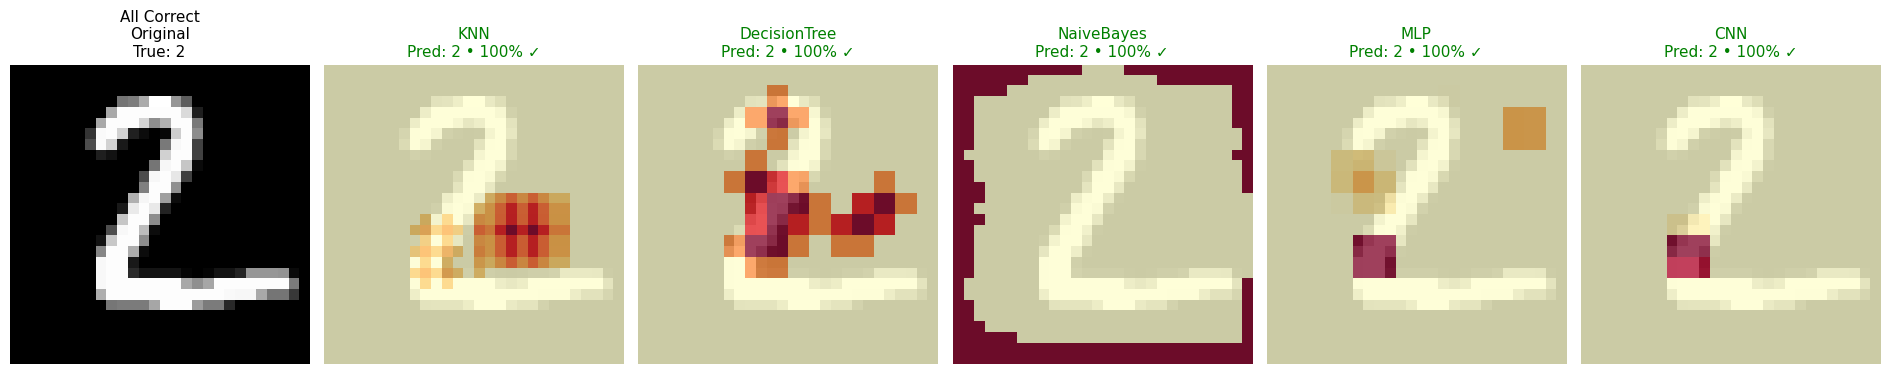

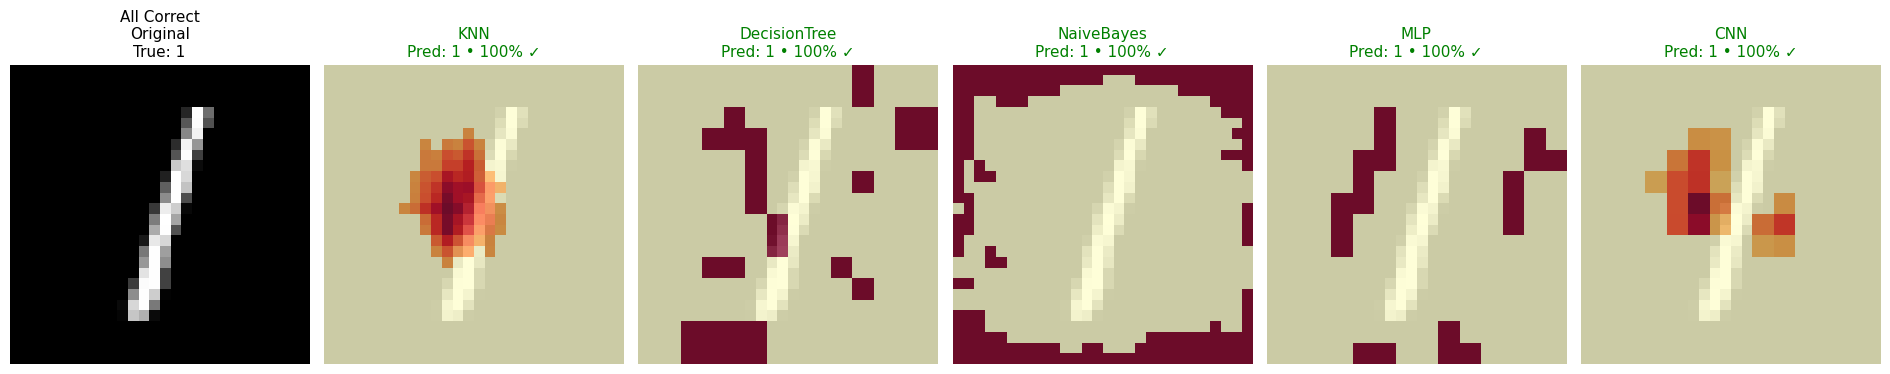

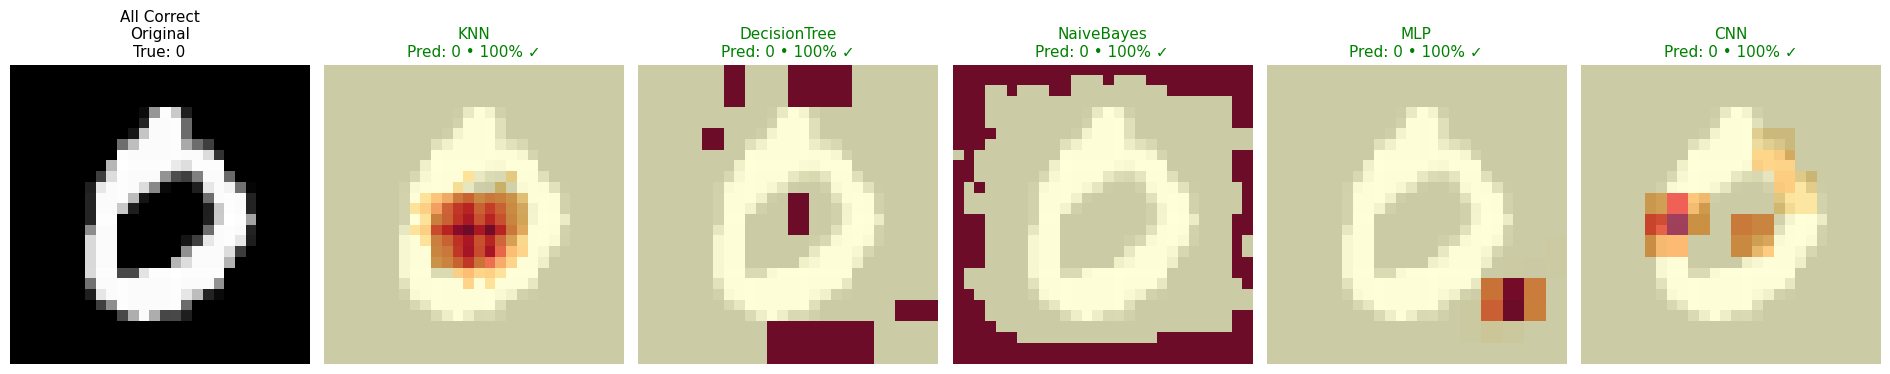

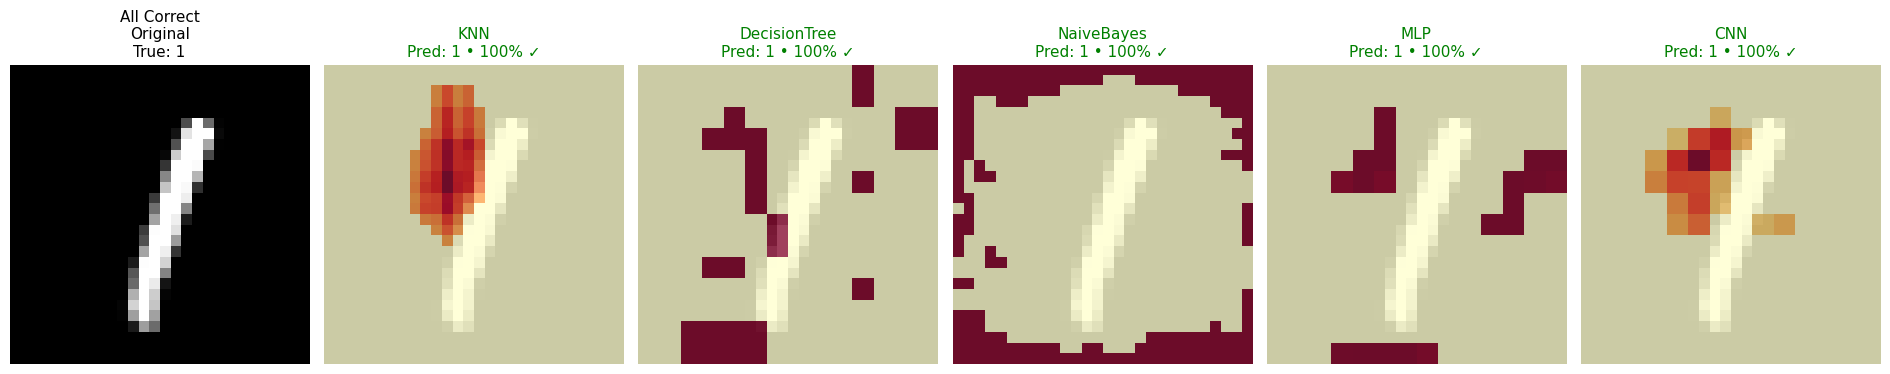

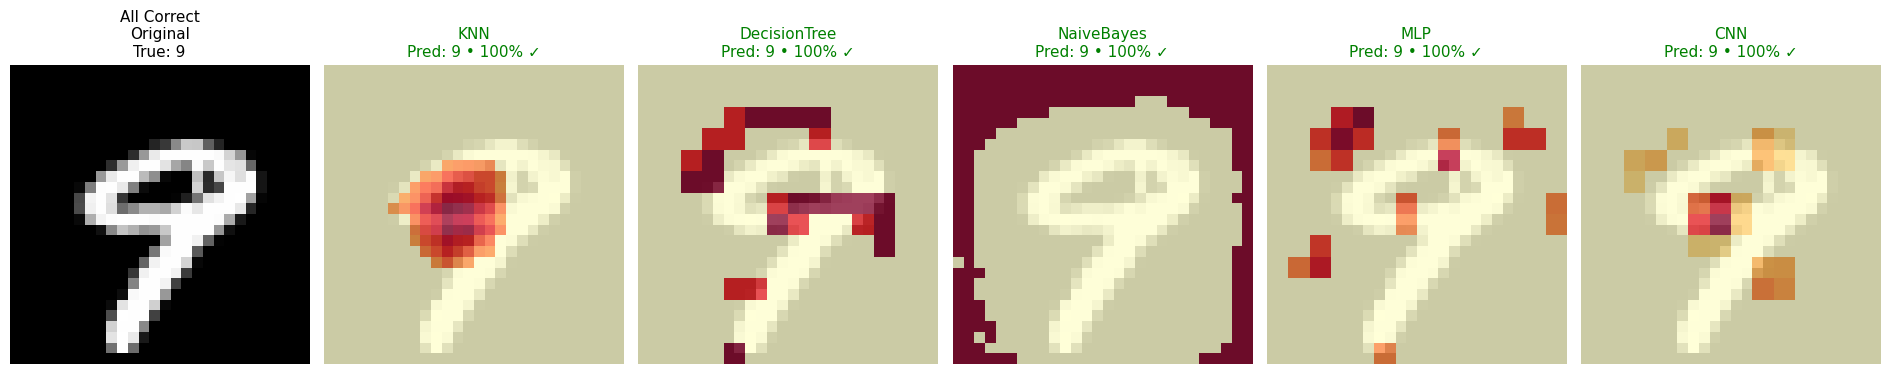

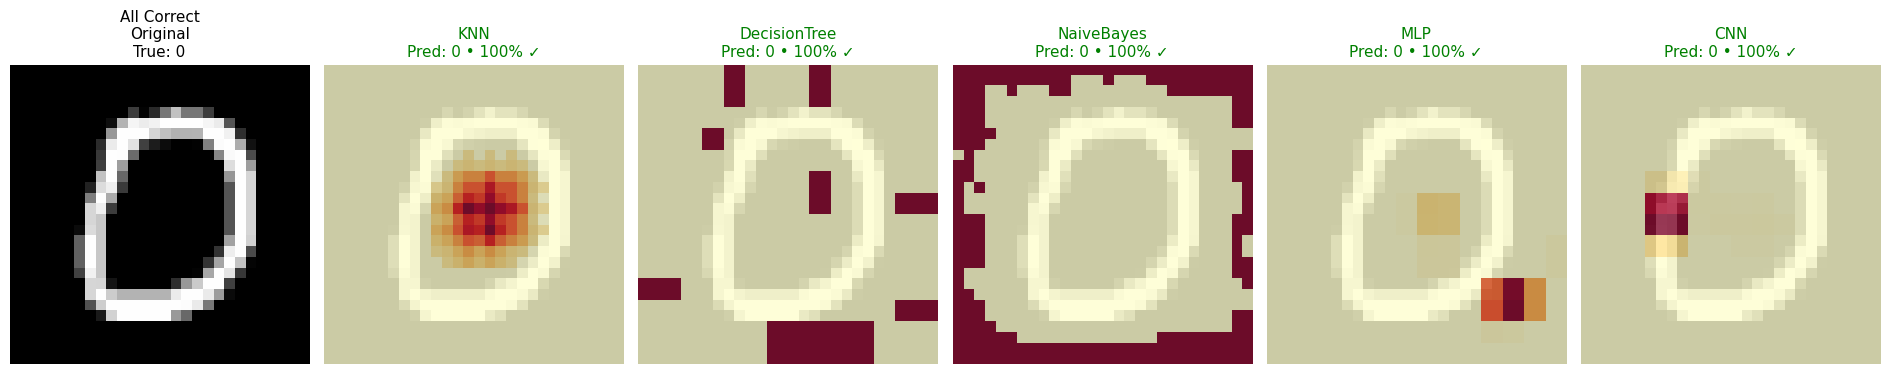


=== Cohort 2: CNN Right, Others Wrong (10 examples) ===


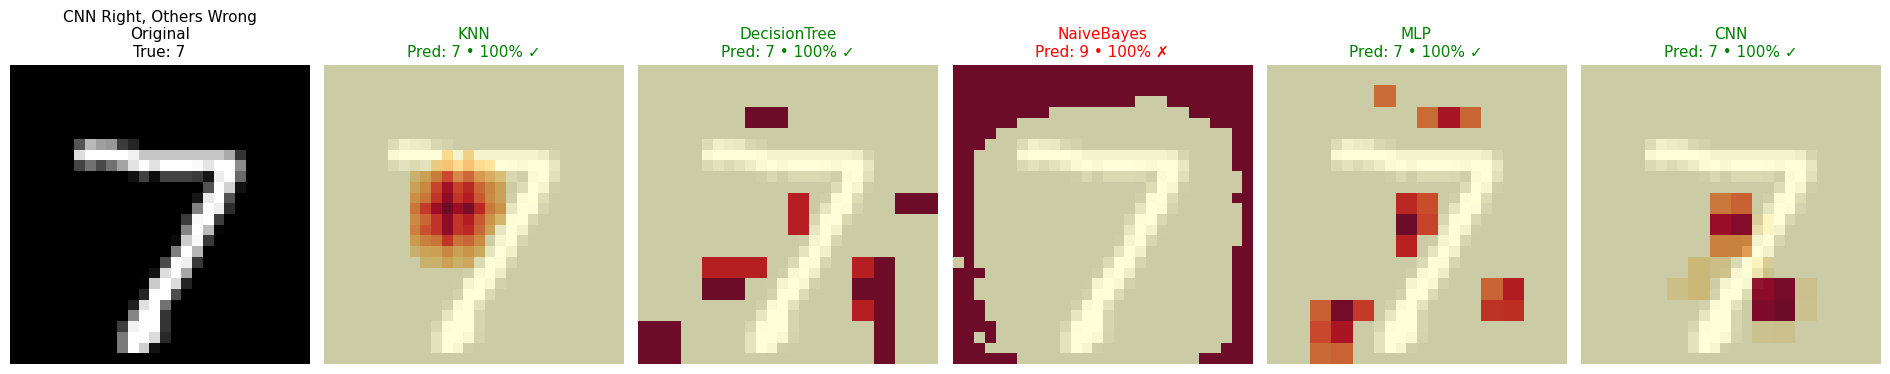

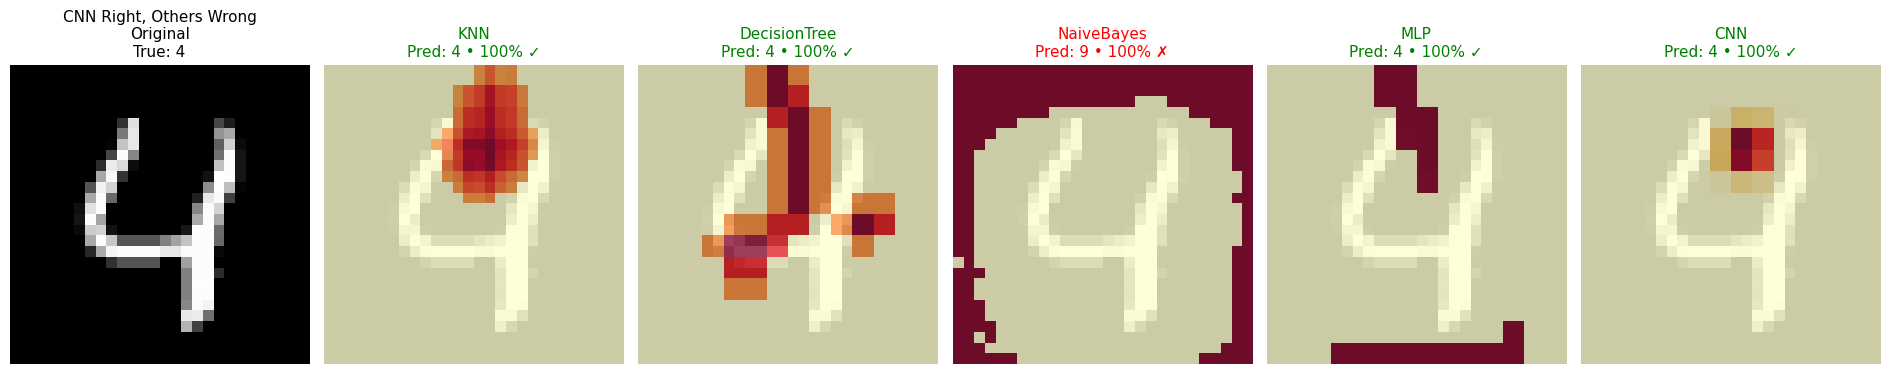

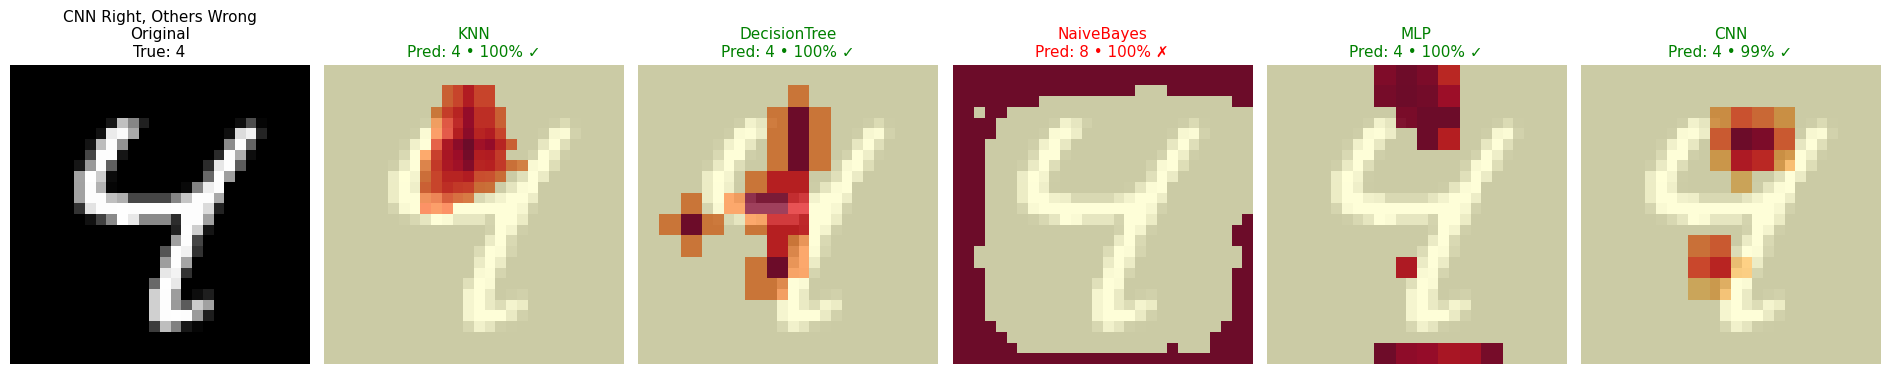

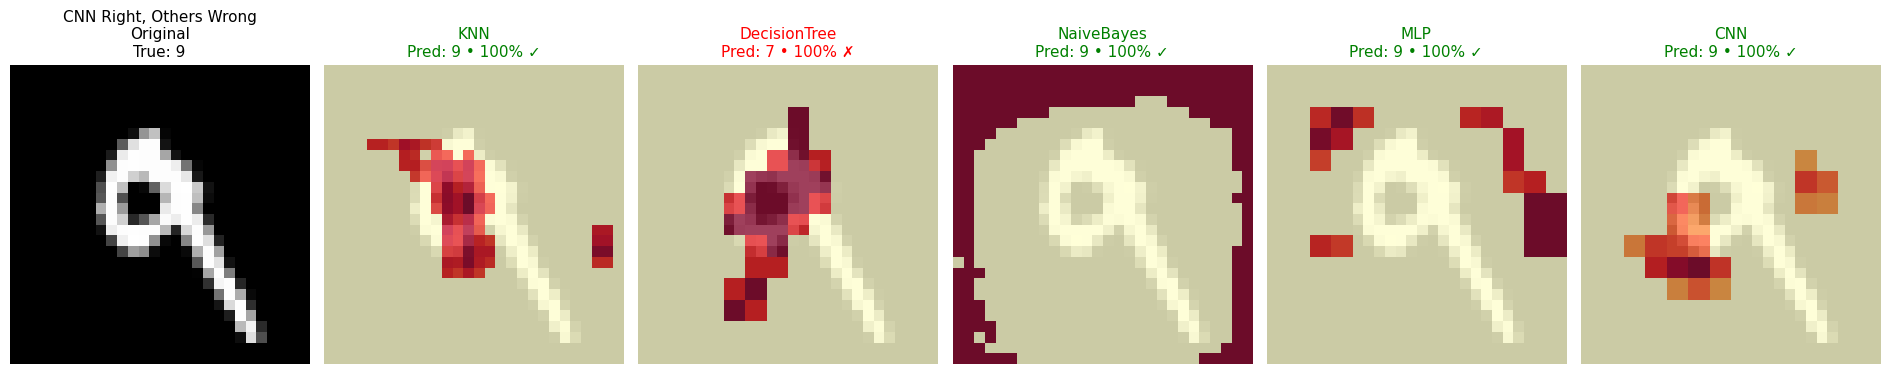

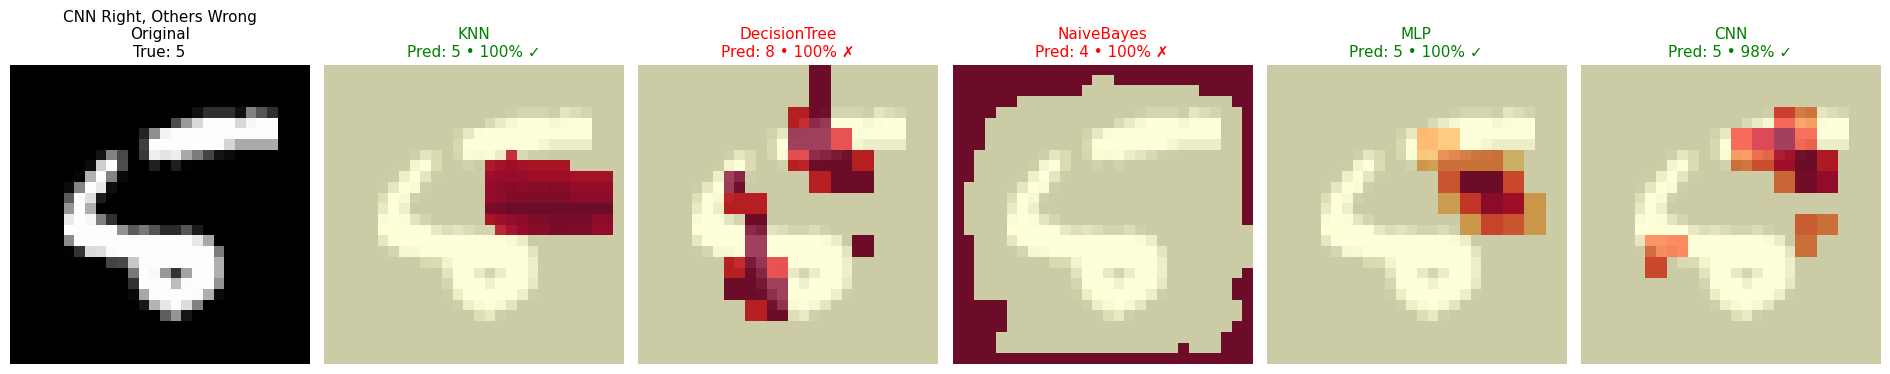

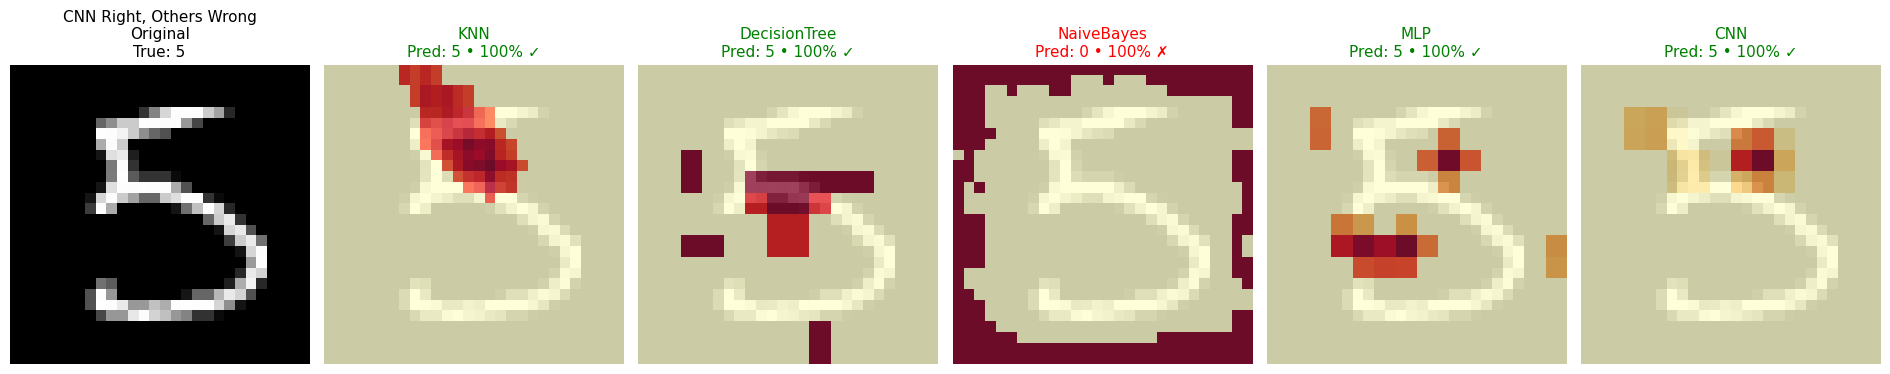

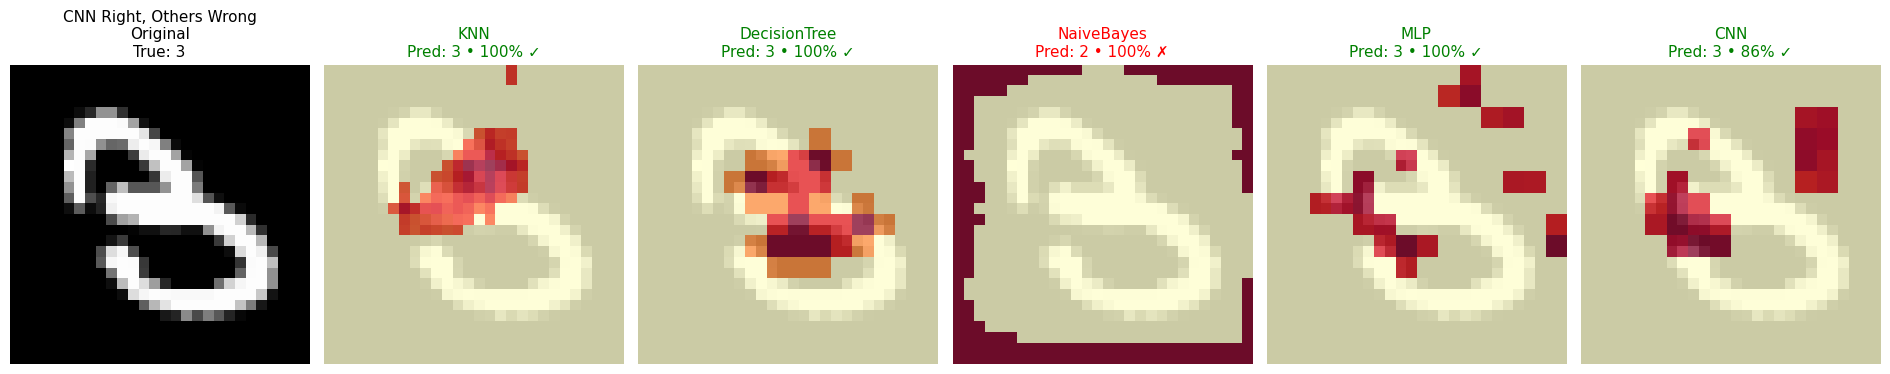

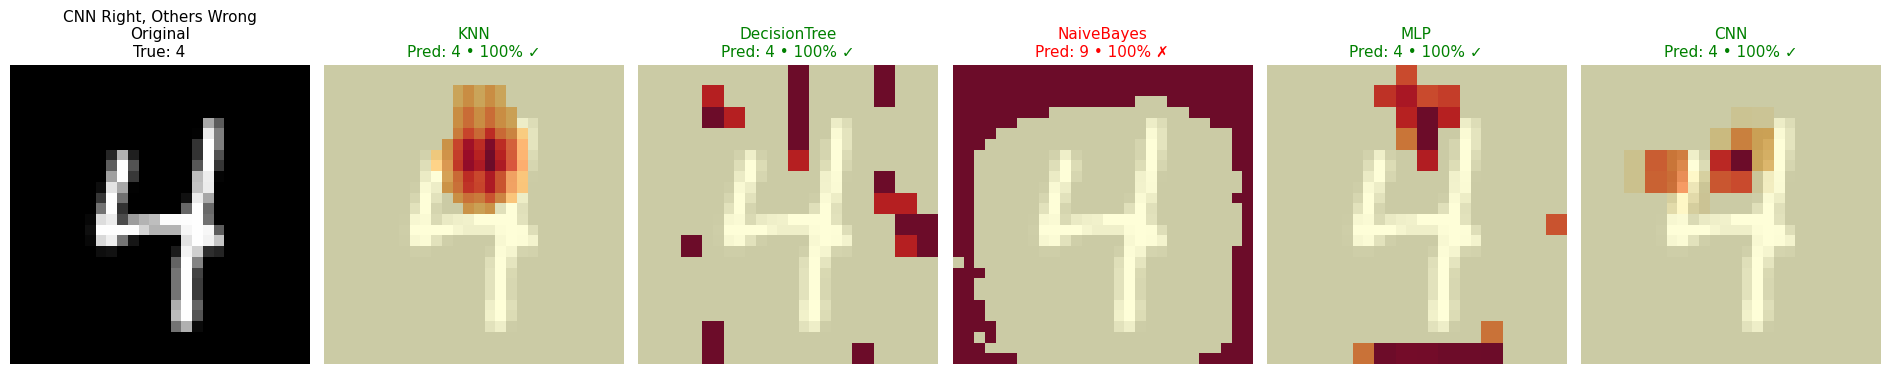

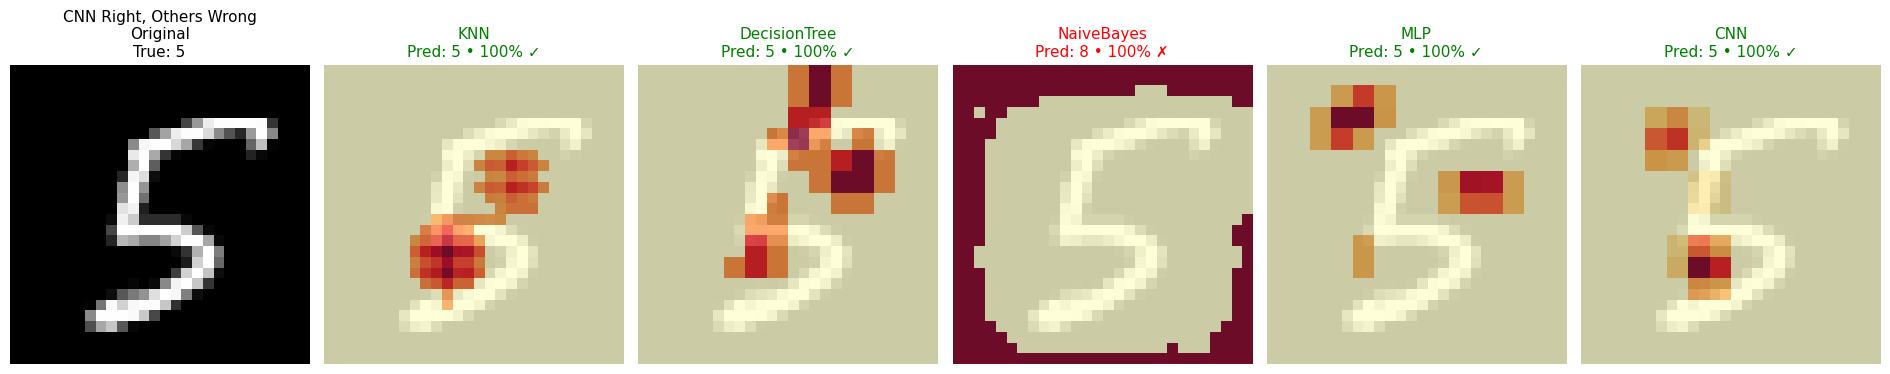

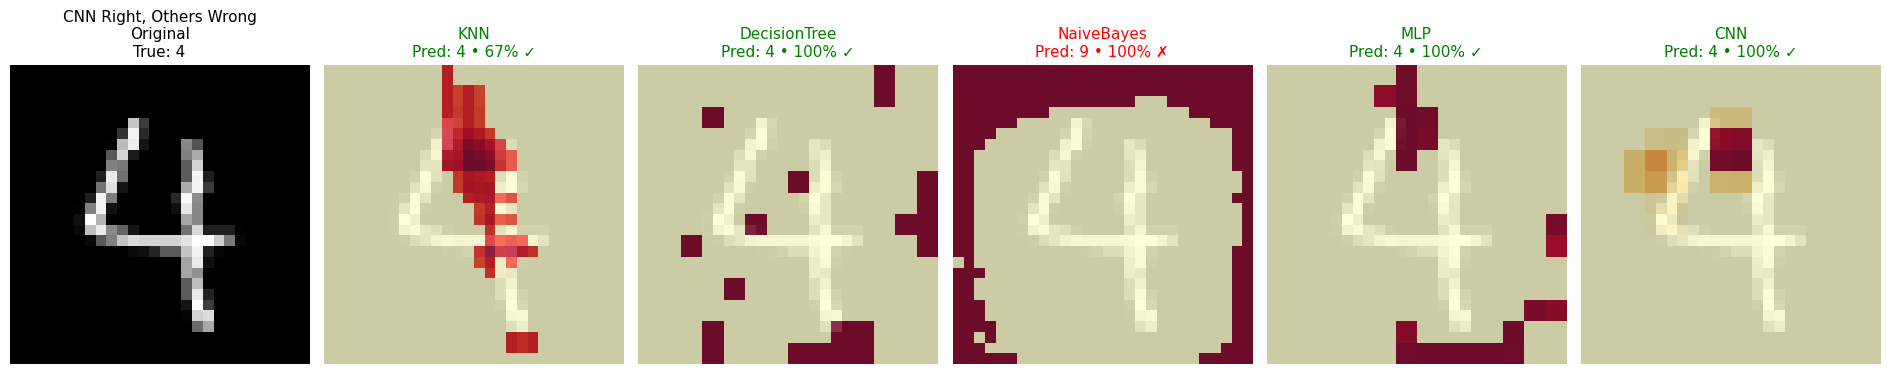


=== Cohort 3: All Wrong (6 examples) ===


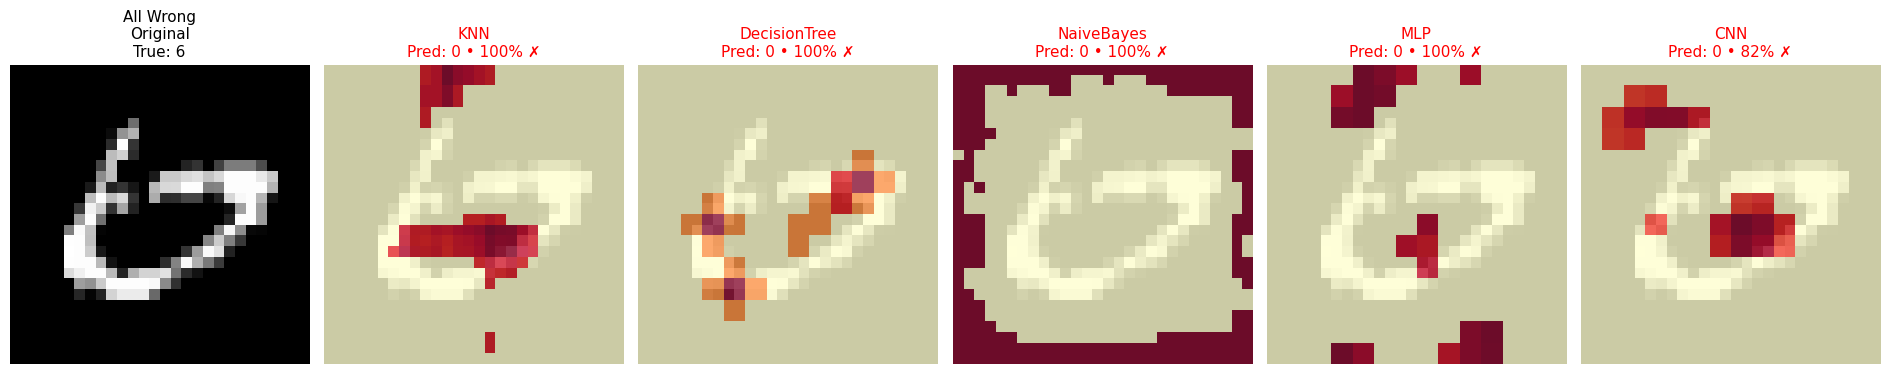

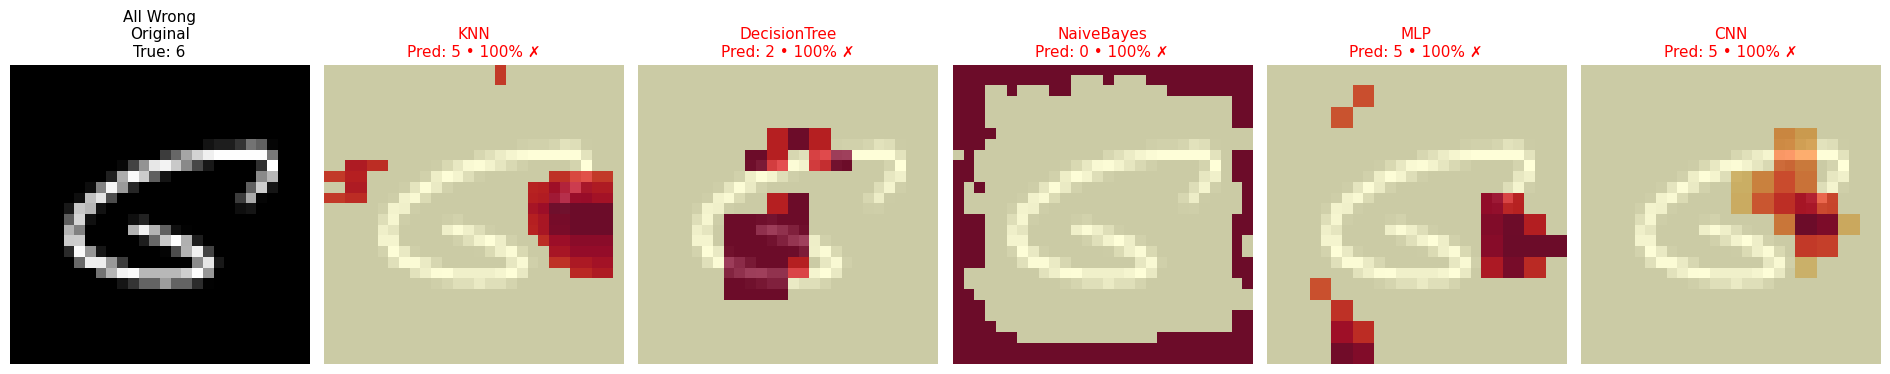

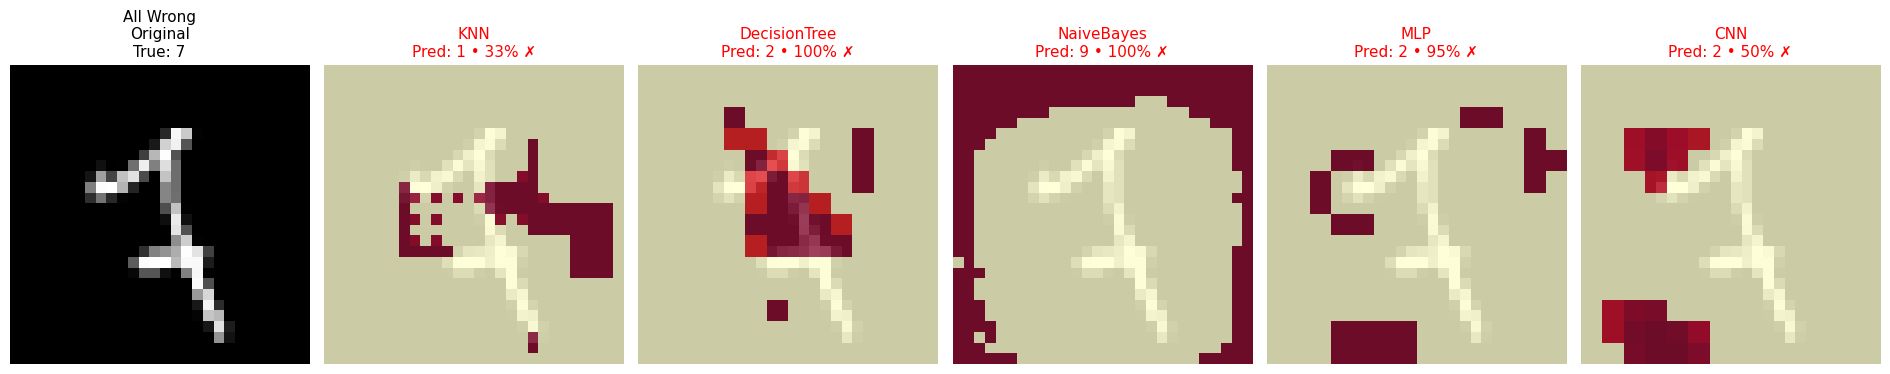

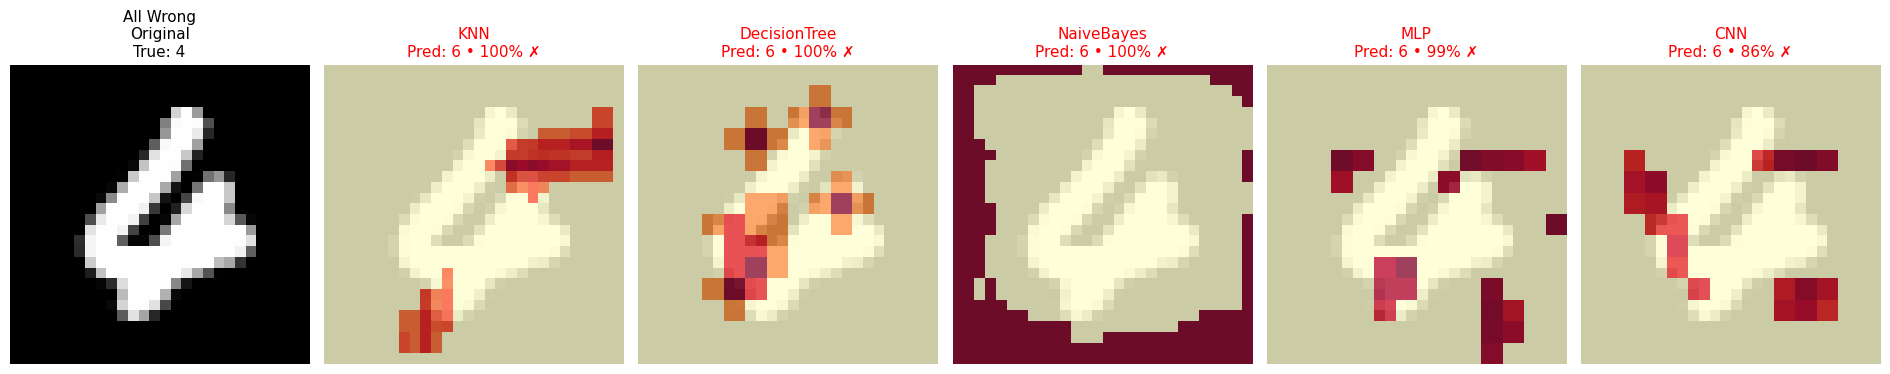

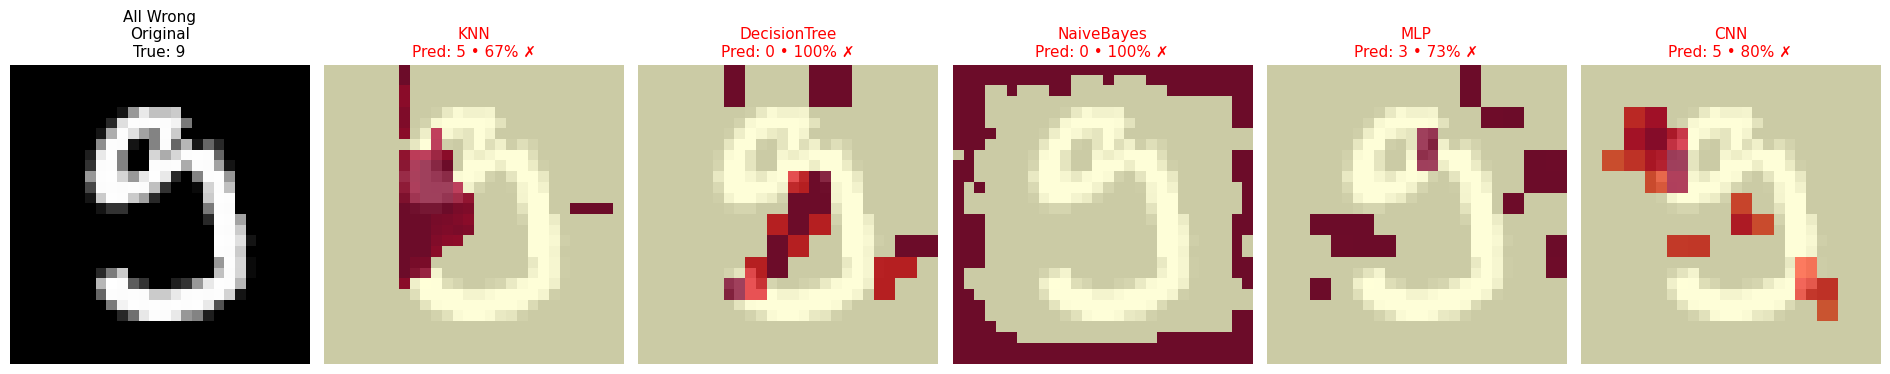

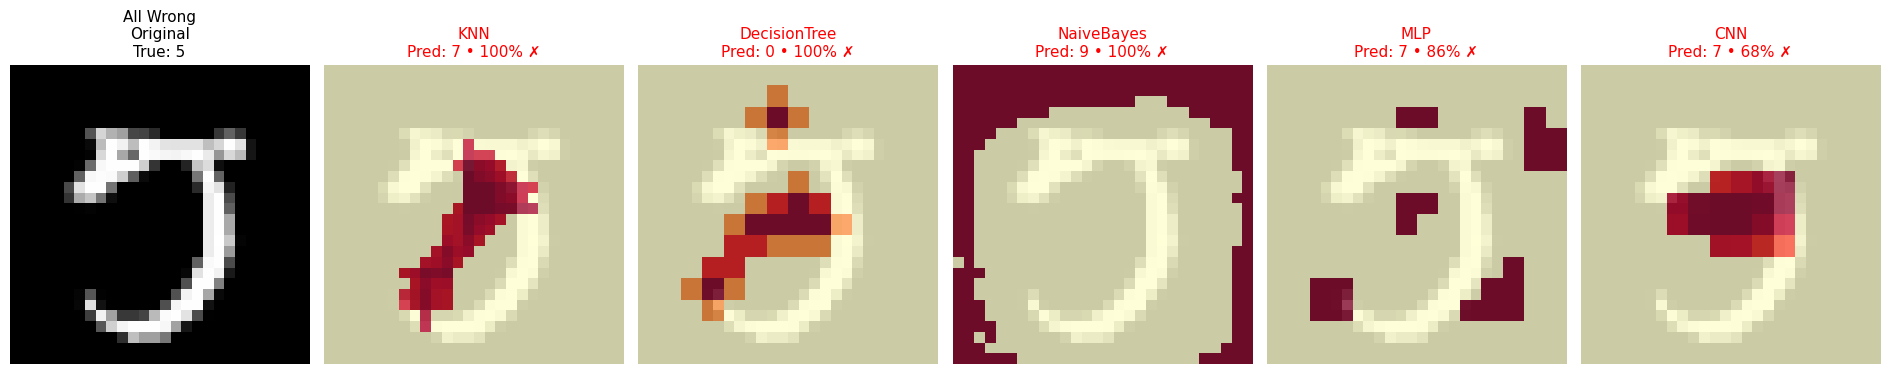

In [ ]:
def render(indices, title):
    for idx in indices:
        x_img = X_test[idx].reshape(28, 28)
        y_true = int(y_test[idx])
        panels = []

        # --- KNN Panel ---
        name, clf = "KNN", models_sklearn["KNN"]
        proba = clf.predict_proba(X_test[idx:idx+1])[0]; pred = int(np.argmax(proba)); conf = float(proba[pred])
        imp,_,_,mask = simple_importance_map_any(clf, x_img, model_name=name); ok = (pred == y_true)
        panels.append((name, imp, pred, conf, ok, mask))

        # --- DecisionTree Panel ---
        name, clf = "DecisionTree", models_sklearn["DecisionTree"]
        proba = clf.predict_proba(X_test[idx:idx+1])[0]; pred = int(np.argmax(proba)); conf = float(proba[pred])
        imp,_,_,mask = simple_importance_map_any(clf, x_img, model_name=name); ok = (pred == y_true)
        panels.append((name, imp, pred, conf, ok, mask))

        # --- NaiveBayes Panel ---
        name, clf = "NaiveBayes", models_sklearn["NaiveBayes"]
        proba = clf.predict_proba(X_test[idx:idx+1])[0]; pred = int(np.argmax(proba)); conf = float(proba[pred])
        nb_contrib = nb_pixel_contrib(clf, x_img, pred_class=pred)
        nb_mask = (np.abs(nb_contrib) >= np.quantile(np.abs(nb_contrib), 0.90)); ok = (pred == y_true)
        panels.append((name, nb_contrib, pred, conf, ok, nb_mask))

        # --- MLP Panel ---
        name, clf = "MLP", models_sklearn["MLP"]
        proba = clf.predict_proba(X_test[idx:idx+1])[0]; pred = int(np.argmax(proba)); conf = float(proba[pred])
        imp,_,_,mask = simple_importance_map_any(clf, x_img, model_name=name); ok = (pred == y_true)
        panels.append((name, imp, pred, conf, ok, mask))

        # --- CNN Panel ---
        name = "CNN"
        proba = predict_proba_any(cnn, x_img); pred = int(np.argmax(proba)); conf = float(proba[pred])
        imp,_,_,mask = simple_importance_map_any(cnn, x_img, model_name=name); ok = (pred == y_true)
        panels.append((name, imp, pred, conf, ok, mask))

        # --- Show the row in fixed order ---
        order = ["KNN","DecisionTree","NaiveBayes","MLP","CNN"]
        panels_sorted = [next(p for p in panels if p[0] == nm) for nm in order]
        show_row(idx, x_img, y_true, panels_sorted, title)

print("\n=== Cohort 1: All Correct (6 examples) ===")
render(idxs_all_correct, "All Correct")

print("\n=== Cohort 2: CNN Right, Others Wrong (10 examples) ===")
render(idxs_cnn_wins, "CNN Right, Others Wrong")

print("\n=== Cohort 3: All Wrong (6 examples) ===")
render(idxs_all_wrong, "All Wrong")

**Explanation:** Each row shows the original image plus five model panels. Each panel shows the model's prediction, its confidence, and a red/green status. The brighter areas on the overlay mean “this part mattered more,” which is easily narratable to an audience without any ML jargon.

## 11) Optional: Deep Dive on KNN

--- KNN Deep Dive ---


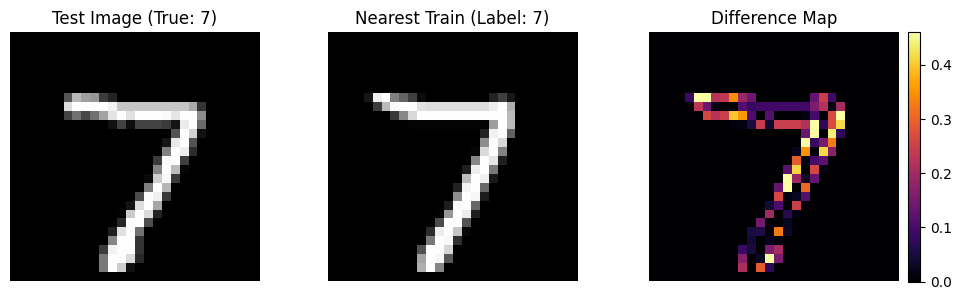

In [ ]:
SHOW_KNN_NEAREST = True  # set True to reveal KNN's nearest training image

if SHOW_KNN_NEAREST:
    print("--- KNN Deep Dive ---")
    # Pick one of the examples where the CNN won
    idx = idxs_cnn_wins[0]

    # Find the single nearest neighbor in the training set
    # Note: We already fit the KNN model in cell 5
    dist, ind = models_sklearn["KNN"].kneighbors(X_test[idx:idx+1], n_neighbors=1, return_distance=True)

    test_img = X_test[idx].reshape(28,28)
    nn_img = X_train[ind[0,0]].reshape(28,28)
    nn_label = y_train[ind[0,0]]
    diff = np.abs(test_img - nn_img)

    fig, ax = plt.subplots(1,3, figsize=(10,3))

    ax[0].imshow(test_img, cmap="gray");
    ax[0].set_title(f"Test Image (True: {y_test[idx]})");
    ax[0].axis("off")

    ax[1].imshow(nn_img, cmap="gray");
    ax[1].set_title(f"Nearest Train (Label: {nn_label})");
    ax[1].axis("off")

    vmax = np.percentile(diff, 99.0) if np.max(diff)>0 else 1.0
    im = ax[2].imshow(diff, cmap="inferno", vmin=0.0, vmax=vmax);
    ax[2].set_title("Difference Map");
    ax[2].axis("off")

    plt.colorbar(im, ax=ax[2], fraction=0.046, pad=0.03)
    plt.tight_layout()
    plt.show()

**Explanation:** KNN literally matches new images to the most similar examples it saw during training. By showing the *single nearest training image* and a simple difference map, we can make its behavior (and its mistakes) intuitive in a single glance.

## 12) Wrap-up & Key Takeaways

* **CNN (Winner):** The CNN almost always wins because its convolutional filters learn to recognize local stroke features (edges, curves, loops) that generalize well to new handwriting. This is why it performs so well.

* **KNN:** This model can be surprisingly strong on MNIST because many digits are near-duplicates. However, it relies on *similar stored examples* rather than *learned features*, which can fail if a new digit is written in a unique way.

* **Decision Trees & Naive Bayes:** These are fast and simple baselines, but they tend to fail. They focus on per-pixel rules or independence assumptions (in the case of NB) that are not robust for image data compared to the learned patterns of an MLP or CNN.

* **Conclusion:** This notebook kept the code compact, the visuals consistent, and the narration simple (“brighter = mattered more”), making it easy to present to a large audience without ML jargon while still being accurate.

Occlusion woriing with probabilities changing and animation generation

Occlusion working animation

KeyboardInterrupt: 

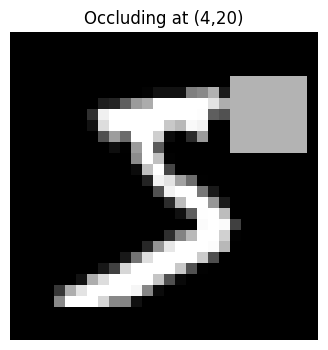

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output
import time

# Select a training image to demonstrate occlusion
# Let's pick the first image from the training set, reshape it to 28x28
example_idx = 0
original_image_flat = X_train[example_idx]
original_image = original_image_flat.reshape(28, 28)

# Define occlusion parameters
window_size = 7  # Size of the square patch to occlude
stride = 2       # How many pixels the patch moves each step

print(f"Demonstrating occlusion on training image (True label: {y_train[example_idx]})\n")

fig, ax = plt.subplots(figsize=(4, 4))
ax.axis('off')

# Loop through the image, moving the occlusion patch
for r in range(0, original_image.shape[0] - window_size + 1, stride):
    for c in range(0, original_image.shape[1] - window_size + 1, stride):
        occluded_image = original_image.copy()
        occluded_image[r:r+window_size, c:c+window_size] = 0.7  # Occlude with black

        ax.imshow(occluded_image, cmap='gray')
        ax.set_title(f'Occluding at ({r},{c})')

        display(fig)
        clear_output(wait=True)
        time.sleep(0.05) # Small pause for animation effect

# Display the original image at the end
ax.imshow(original_image, cmap='gray')
ax.set_title('Original Image (End of Occlusion Demo)')
display(fig)
plt.close(fig) # Close the figure to prevent it from being displayed twice


# Task
Generate a single, well-organized Matplotlib panel displaying the CNN occlusion sensitivity maps for one correctly classified example of each digit (0-9) from the test set, with each digit showing its original image and the corresponding 'brighter = mattered more' importance map side-by-side.

## Select Correctly Classified Digits for CNN

### Subtask:
Identify one example from the test set for each digit (0-9) that the CNN model classified correctly.


**Reasoning**:
First, I'll obtain the CNN's predictions for the test set and determine which of these predictions are correct when compared to the true labels. This will form the basis for identifying correctly classified digits.



In [ ]:
import numpy as np

# 1. Get the CNN predictions for the entire test set
cnn_predictions_proba = cnn.predict(X_test_img, verbose=0)
cnn_predictions = np.argmax(cnn_predictions_proba, axis=1)

# 2. Create a boolean mask indicating where the CNN's predictions match the true labels
cnn_correct_mask = (cnn_predictions == y_test)

print("CNN predictions obtained and correctness mask created.")

CNN predictions obtained and correctness mask created.


**Reasoning**:
Now that the CNN predictions and correctness mask are available, I will initialize a dictionary to store the indices of correctly classified examples for each digit. Then, I will iterate through each digit from 0 to 9 to find and store the first instance where the CNN correctly classified that digit.



In [ ]:
cnn_correct_indices_per_digit = {}

# 3. Loop through each digit from 0 to 9
for digit in range(10):
    # a. Find all indices in the test set where the true label is the current digit
    true_label_indices = np.where(y_test == digit)[0]

    # b. From these indices, filter for those where the CNN also made a correct prediction
    correct_for_this_digit_mask = cnn_correct_mask[true_label_indices]
    correct_for_this_digit_indices = true_label_indices[correct_for_this_digit_mask]

    # c. Select the first index from this filtered list (if available) and store it
    if len(correct_for_this_digit_indices) > 0:
        cnn_correct_indices_per_digit[digit] = correct_for_this_digit_indices[0]

print("Indices of correctly classified examples for each digit (0-9) by CNN:")
for digit, idx in cnn_correct_indices_per_digit.items():
    print(f"Digit {digit}: Test index {idx}")

# Make sure we found one for each digit
if len(cnn_correct_indices_per_digit) == 10:
    print("Successfully found at least one correctly classified example for each digit (0-9).")
else:
    print("Warning: Could not find a correctly classified example for all digits.")

Indices of correctly classified examples for each digit (0-9) by CNN:
Digit 0: Test index 3
Digit 1: Test index 2
Digit 2: Test index 1
Digit 3: Test index 30
Digit 4: Test index 4
Digit 5: Test index 8
Digit 6: Test index 11
Digit 7: Test index 0
Digit 8: Test index 61
Digit 9: Test index 7
Successfully found at least one correctly classified example for each digit (0-9).


In [ ]:
import matplotlib.animation as animation
import IPython.display as display

# Ensure `cnn` is available, assuming it's trained from previous cells.
# Ensure `predict_proba_any` is defined from previous cells.

# Select an example image (e.g., the first training image)
# MODIFIED: Using test_idx=0 (digit 7) for consistency with heatmap example
example_idx = 0
original_image_flat = X_test[example_idx]
original_image = original_image_flat.reshape(28, 28)
true_label = y_test[example_idx]

# Define occlusion parameters
window_size = 7
stride = 2

H, W = original_image.shape

# Create a figure with two subplots
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(f'Occlusion Animation (True: {true_label})', fontsize=16)

# Initialize image subplot
img_plot = ax_img.imshow(original_image, cmap='gray')
ax_img.set_title('Original Image')
ax_img.axis('off')

# Initialize bar chart subplot
digits = np.arange(10)
bar_plot = ax_bar.bar(digits, np.zeros(10), color='skyblue')
ax_bar.set_ylim(0, 1) # Probabilities are between 0 and 1
ax_bar.set_xticks(digits)
ax_bar.set_title('CNN Predicted Probabilities')
ax_bar.set_xlabel('Digit Class')
ax_bar.set_ylabel('Probability')

def update(frame):
    occluded_image = original_image.copy()
    current_image_title = 'Original Image'

    if frame < (H - window_size + stride) // stride * ((W - window_size + stride) // stride):
        # Calculate row and column for occlusion patch
        num_cols = (W - window_size + stride) // stride
        r_idx = frame // num_cols
        c_idx = frame % num_cols

        r = r_idx * stride
        c = c_idx * stride

        # Occlude with lighter gray (0.7)
        occluded_image[r:r+window_size, c:c+window_size] = 0.7
        current_image_title = f'Occluding at ({r},{c})'

    # Get CNN predictions for the current occluded image
    # The predict_proba_any function needs the image in (28,28) format for CNN and reshapes internally
    current_probabilities = predict_proba_any(cnn, occluded_image.reshape(28, 28))
    predicted_class = np.argmax(current_probabilities)
    confidence = current_probabilities[predicted_class]

    # Update image subplot
    img_plot.set_data(occluded_image)
    ax_img.set_title(f'{current_image_title}\nPred: {predicted_class} (Conf: {confidence:.2f})')

    # Update bar chart subplot
    for i, bar in enumerate(bar_plot):
        bar.set_height(current_probabilities[i])

    return [img_plot, ax_img.title] + list(bar_plot) # Return all updated artists

# Calculate total number of frames needed
# Number of steps in rows * Number of steps in columns
num_row_steps = (H - window_size + stride) // stride
num_col_steps = (W - window_size + stride) // stride
total_occlusion_frames = num_row_steps * num_col_steps

# Add one extra frame for the final original image state
total_frames = total_occlusion_frames + 1

# Create the animation
print("Generating animation... This may take a few minutes.")
anim = animation.FuncAnimation(fig, update, frames=total_frames, blit=True, interval=100)

# Save the animation as an MP4 video file
output_filename = 'occlusion_animation.mp4'
anim.save(output_filename, writer='ffmpeg', dpi=100)

plt.close(fig) # Close the figure to prevent it from being displayed inline before the video

print(f"Animation saved to {output_filename}")

# Display the video and provide a download link
display.display(display.Video(output_filename, embed=True))

# Provide a direct download link (optional, for environments that support it)
print(f"Direct download link: <a href='{output_filename}' download>Download MP4</a>")

Generating animation... This may take a few minutes.
Animation saved to occlusion_animation.mp4


Direct download link: <a href='occlusion_animation.mp4' download>Download MP4</a>


**Reasoning**:
Now that we have identified one correctly classified example for each digit (0-9) by the CNN, I will generate a single Matplotlib figure with subplots. Each subplot pair will show the original image and its corresponding CNN occlusion sensitivity map for one digit, iterating from 0 to 9.



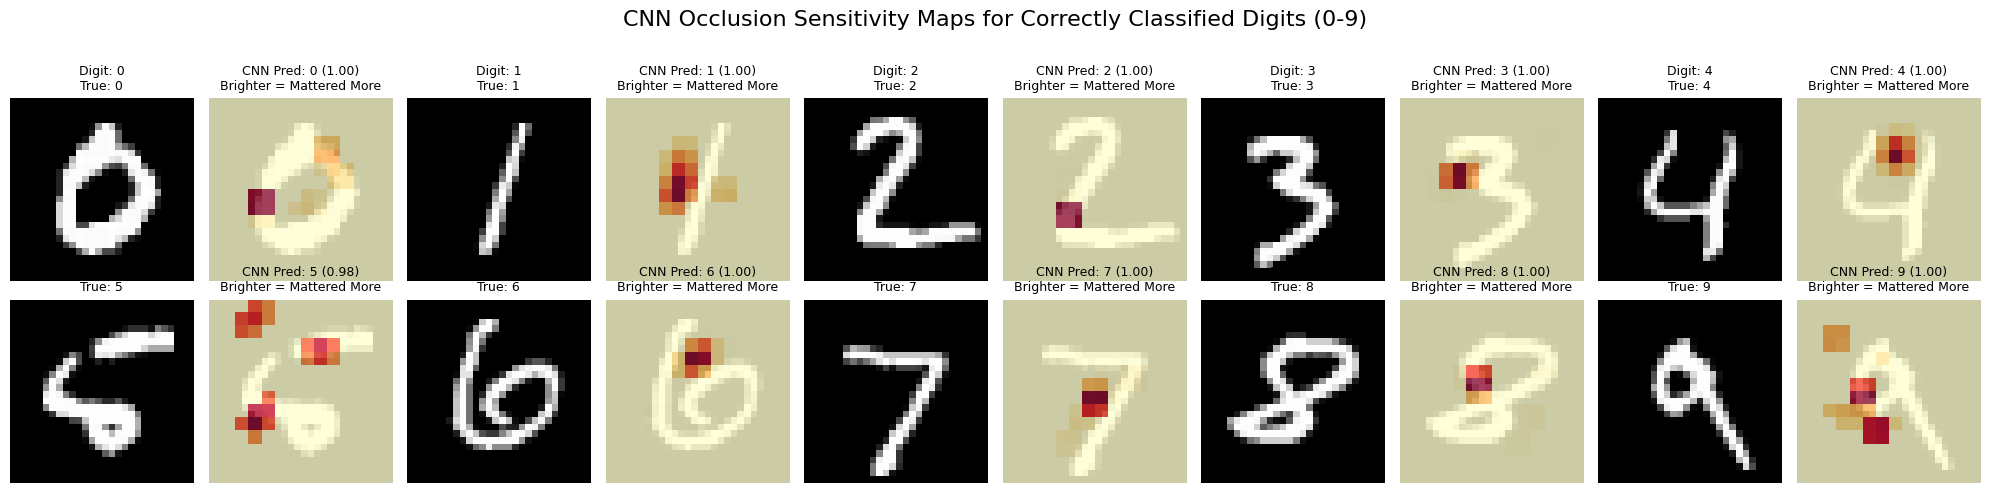

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sort the dictionary by digit for consistent plotting order
sorted_indices = sorted(cnn_correct_indices_per_digit.items())

# Setup the figure and subplots for a more compact layout
# We want 10 digits, each with 2 subplots (original + importance map)
# Let's arrange them in 2 rows, 5 digits per row. This means 2 rows x (5 digits * 2 columns/digit) = 2 rows x 10 columns
fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(20, 5))
fig.suptitle('CNN Occlusion Sensitivity Maps for Correctly Classified Digits (0-9)', fontsize=16, y=1.02) # Adjusted y for suptitle

for i, (digit, idx) in enumerate(sorted_indices):
    x_img_flat = X_test[idx]
    x_img = x_img_flat.reshape(28, 28)
    y_true = int(y_test[idx])

    # Generate importance map for the CNN model
    imp, pred, base_conf, mask = simple_importance_map_any(cnn, x_img, model_name='CNN')

    # Determine subplot position
    row_idx = i // 5       # 0 for first 5 digits, 1 for last 5 digits
    col_start = (i % 5) * 2 # 0, 2, 4, 6, 8 for columns

    # Plot Original Image
    current_ax_orig = axes[row_idx, col_start]
    current_ax_orig.imshow(x_img, cmap='gray')
    current_ax_orig.set_title(f'Digit: {digit}\nTrue: {y_true}', fontsize=9)
    current_ax_orig.axis('off')

    # Plot Importance Map (Overlayed)
    current_ax_imp = axes[row_idx, col_start + 1]
    current_ax_imp.imshow(x_img, cmap='gray', alpha=0.8)
    if mask is not None and np.any(mask):
        vmax = np.percentile(imp[mask], 99.0) if np.any(imp[mask]) and np.max(imp[mask]) > 0 else None
        if vmax is None or vmax == 0:
            vmax = np.max(imp) if np.max(imp) > 0 else 1.0

        overlay_to_show = np.zeros_like(imp)
        overlay_to_show[mask] = imp[mask]

        current_ax_imp.imshow(overlay_to_show, cmap='YlOrRd', alpha=0.75, vmin=0.0, vmax=vmax)
    else:
        current_ax_imp.text(0.5, 0.5, "No standout region", color="orange", ha="center", va="center", transform=current_ax_imp.transAxes, fontsize=8)

    current_ax_imp.set_title(f'CNN Pred: {pred} ({base_conf:.2f})\nBrighter = Mattered More', fontsize=9)
    current_ax_imp.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
plt.show()

## Final Task

### Subtask:
Confirm that a single, well-organized panel displaying the CNN occlusion sensitivity maps for all 10 digits (0-9) is successfully generated and clearly illustrates the regions the CNN focused on for each digit.


Generating Occlusion sensitivity for digit 5 for slides

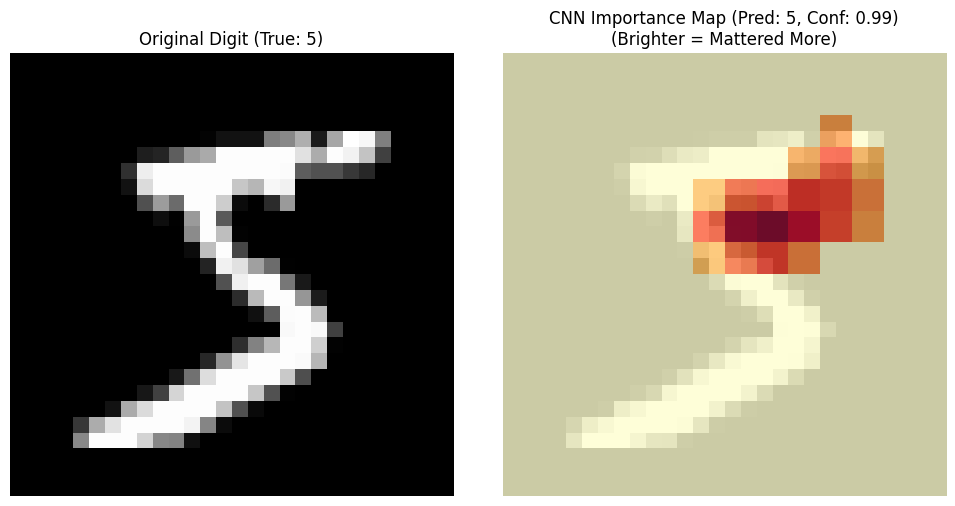

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


x_img_flat = X_train[0]
x_img = x_img_flat.reshape(28, 28)
y_true = int(y_train[0])

# Generate importance map for the CNN model
imp, pred, base_conf, mask = simple_importance_map_any(cnn, x_img, model_name='CNN')

# Create the plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original Image
axes[0].imshow(x_img, cmap='gray')
axes[0].set_title(f'Original Digit (True: {y_true})')
axes[0].axis('off')

# Importance Map (Overlayed)
axes[1].imshow(x_img, cmap='gray', alpha=0.8)
# Only show the top 10% brightest parts for clarity if mask is available and not empty
if mask is not None and np.any(mask):
    # Ensure vmax is calculated only from positive, masked values to avoid issues
    vmax = np.percentile(imp[mask], 99.0) if np.any(imp[mask]) and np.max(imp[mask]) > 0 else None
    # If vmax is still None or 0, set a default to make sure colormap works
    if vmax is None or vmax == 0:
        vmax = np.max(imp) if np.max(imp) > 0 else 1.0 # Fallback to max or 1.0

    # Create an overlay where only masked regions are shown
    overlay_to_show = np.zeros_like(imp)
    overlay_to_show[mask] = imp[mask]

    axes[1].imshow(overlay_to_show, cmap='YlOrRd', alpha=0.75, vmin=0.0, vmax=vmax)
else:
    axes[1].text(0.5, 0.5, "No standout region", color="orange", ha="center", va="center", transform=axes[1].transAxes)

axes[1].set_title(f'CNN Importance Map (Pred: {pred}, Conf: {base_conf:.2f})\n(Brighter = Mattered More)')
axes[1].axis('off')

plt.tight_layout()
plt.show()